In [1]:
from spyplotter import Spectrum
import astropy.units as u

# Direct comparison of measured photometry fluxes with simulated SEDs

## Import model spectrum

In [22]:
spectrum_contplines = Spectrum.from_powr(
    filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',
    keywords=['OPT'],
    dataset=3
)


spyplotter.spectrum - INFO - Flux calibrated spectrum at 10 pc. Thus using erg / (Angstrom s cm2) as y unit.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.


## Scale model to the desried distance
By default, Powr model SEDs are calculated at a distance of 10 pc 

In [23]:
spectrum_contplines.scale_to_distance(to_distance=55*u.kpc,overwrite=True)

<Quantity [3.08130149e-14, 3.08119395e-14, 3.08108965e-14, ...,
           4.37470678e-16, 4.37455769e-16, 4.37440661e-16] erg / (Angstrom s cm2)>

## Redden the spectrum

In [24]:
reddened = spectrum_contplines.redden(ebv=0.2,law='G16',new_spectrum=True)

spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: erg / (Angstrom s cm2)


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


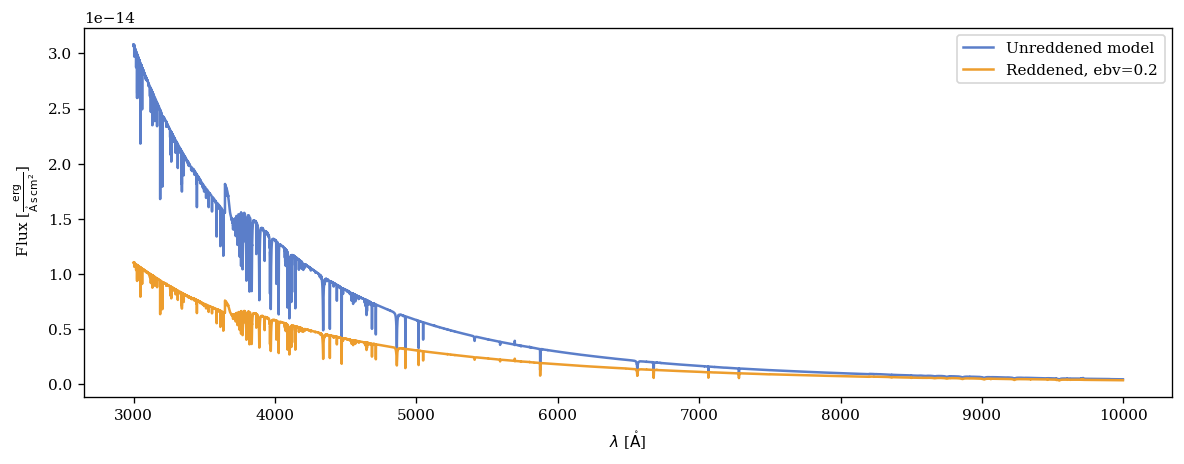

In [25]:
ax= spectrum_contplines.plot(label='Unreddened model ')
reddened.plot(ax=ax,label='Reddened, ebv=0.2')
ax.legend()

## Compare with an observed SED
The recommended way is to extract the magnitudes as a vot table from the Sed VizieR (https://vizier.cds.unistra.fr/vizier/sed/).
By default, the x unit is converted to Angstroms and the y-unit to $\mathrm{erg\, A^{-1} s^{-1} cm^{-2^{-1}}}$ as the default unit of the PoWR models

In [26]:
vottable = Spectrum.from_votable('../tests/test_data/star_photometry.vot',x_unit_out=u.AA,y_unit_out=u.erg/u.AA/u.s/(u.cm**2))

spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: erg / (Angstrom s cm2)


## Now, compare both model, and observed SEDs

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


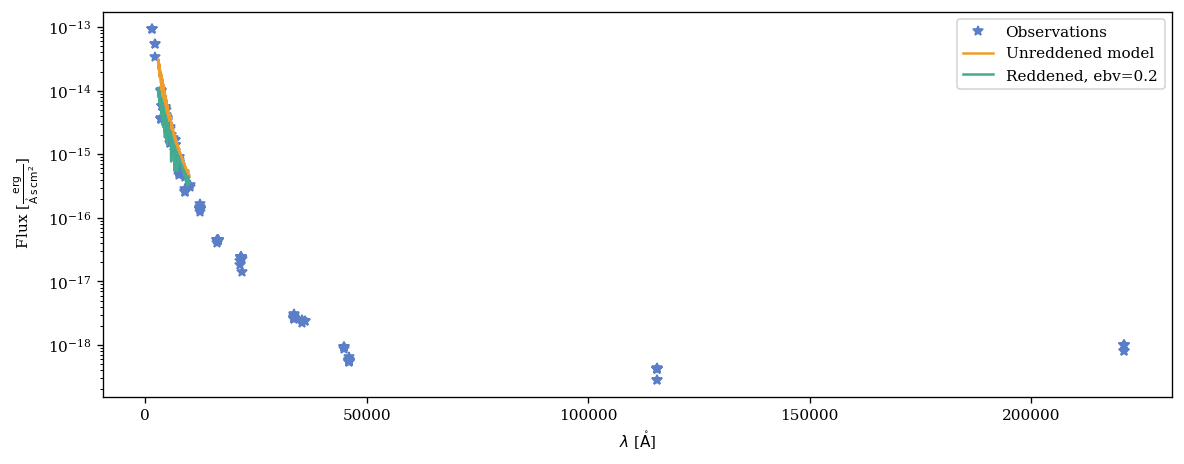

In [27]:
ax= vottable.plot(marker='*',lw=0,label='Observations')
spectrum_contplines.plot(ax=ax,label='Unreddened model ')
reddened.plot(ax=ax,label='Reddened, ebv=0.2')
ax.legend()
ax.set_yscale('log')